### Введение

Данный проект посвящён задаче бессупервизной кластеризации музыкальных треков на основе набора акустических признаков (танцевальность, энергичность, валентность, темп и др.) с применением алгоритмов KMeans и DBSCAN. Работа направлена на выявление скрытых структурных закономерностей в аудиоданных и определение степени соответствия акустических свойств композиций их традиционной жанровой принадлежности.

Основные цели исследования:
- провести сравнительный анализ центроидного и плотностного методов группировки треков;
- определить оптимальные гиперпараметры моделей с использованием методов локтя и силуэтного коэффициента;
- количественно оценить качество полученных разбиений относительно эталонных жанровых меток с помощью скорректированного индекса Рэнда (ARI) и скорректированной взаимной информации (AMI).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('description.txt', 'r', encoding='utf-8') as f:
    content = f.read()
print(content)

Датасет музыкальных треков 

Целевые переменные:
genre - жанр трека
subgenre - поджанр

Целевой переменной является жанр, но если ваших кластеров больше 6, выясните, какие поджанры получается разделить кластеризацией.

Остальные признаки:

track_name, track_artist, track_album_name, track_album_release_date - и так понятно
track_popularity - Song Popularity (0-100) where higher is better
Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable.
Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general ent

In [3]:
df = pd.read_csv('data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_name                32828 non-null  object 
 1   track_artist              32828 non-null  object 
 2   track_album_name          32828 non-null  object 
 3   track_album_release_date  32833 non-null  object 
 4   track_popularity          32833 non-null  int64  
 5   danceability              32833 non-null  float64
 6   energy                    32833 non-null  float64
 7   key                       32833 non-null  int64  
 8   loudness                  32833 non-null  float64
 9   mode                      32833 non-null  int64  
 10  speechiness               32833 non-null  float64
 11  acousticness              32833 non-null  float64
 12  instrumentalness          32833 non-null  float64
 13  liveness                  32833 non-null  float64
 14  valenc

In [4]:
df.isnull().sum()

track_name                  5
track_artist                5
track_album_name            5
track_album_release_date    0
track_popularity            0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
genre                       0
subgenre                    0
dtype: int64

### Предобработка признаков
Для кластеризации отобраны только числовые аудиохарактеристики. Данные масштабируются, чтобы признаки с разным диапазоном значений вносили равный вклад в расчет расстояний. Жанры кодируются числами исключительно для последующей оценки качества кластеризации, в само обучение метки не передаются.

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

X = df[features].copy()
y = df['genre']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


le = LabelEncoder()
y_encoded = le.fit_transform(y)

### Подбор числа кластеров для KMeans
Алгоритм перебирает количество кластеров от 2 до 15. Строится два графика: метод локтя (динамика внутрикластерной инерции) и силуэтный коэффициент (оценка плотности и разделимости групп). Оптимальное значение выбирается по точке перегиба графика инерции и локальному максимуму силуэта.

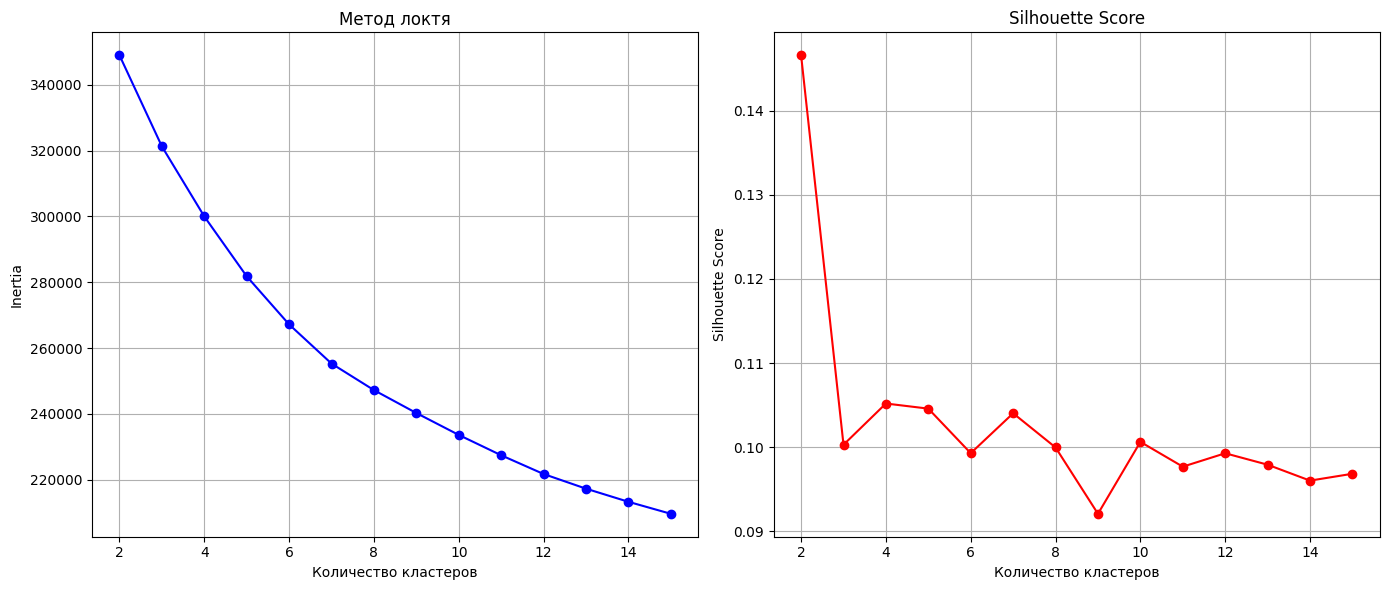

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

max_clusters = 15
inertia = []
silhouette_scores = []

for k in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(range(2, max_clusters + 1), inertia, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, max_clusters + 1), silhouette_scores, 'ro-')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.grid(True)

plt.tight_layout()

### Настройка DBSCAN: радиус окрестности (eps)
Параметр `min_samples` оставлен стандартным, изменяется только радиус поиска соседей `eps`. С ростом радиуса алгоритм объединяет разрозненные группы, что снижает общее количество кластеров и долю точек, помеченных как шум.

In [32]:

outlier_percent = []
number_of_outliers = []
n_clusters = []
eps_val = np.linspace(3,9,30)

for eps in eps_val:

    # Создаём модель
    dbscan = DBSCAN(eps=eps)
    dbscan.fit(X_scaled)

    # Сохраняем количество точек выбросов
    number_of_outliers.append(np.sum(dbscan.labels_ == -1))

    # Сохраняем процент точек-выбросов (количество выбросов как процент от общего количества точек)
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)

    outlier_percent.append(perc_outliers)

    # Сохраняем количество кластеров (метки != -1)
    n_clusters.append(len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0))

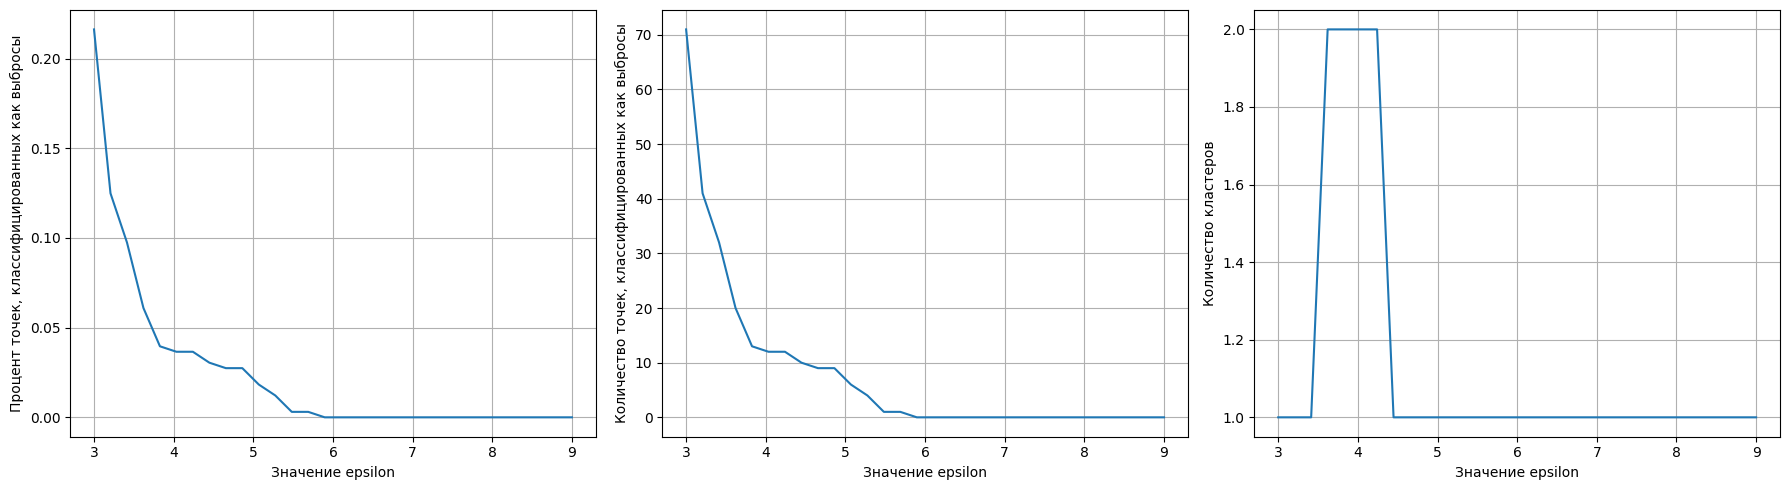

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Первый график: процент выбросов
sns.lineplot(x=eps_val, y=outlier_percent, ax=ax1)
ax1.set_ylabel("Процент точек, классифицированных как выбросы")
ax1.set_xlabel("Значение epsilon")
ax1.grid(True)

# Второй график: количество выбросов
sns.lineplot(x=eps_val, y=number_of_outliers, ax=ax2)
ax2.set_ylabel("Количество точек, классифицированных как выбросы")
ax2.set_xlabel("Значение epsilon")
ax2.grid(True)

# Третий график: количество кластеров
sns.lineplot(x=eps_val, y=n_clusters, ax=ax3)
ax3.set_ylabel("Количество кластеров")
ax3.set_xlabel("Значение epsilon")
ax3.grid(True)

plt.tight_layout()

Графики показывают компромисс между детализацией разбиения и потерей данных.

### Настройка DBSCAN: минимальное число соседей
Радиус `eps` фиксируется на низком значении, меняется порог `min_samples`. Увеличение требования к количеству соседей делает кластеризацию строже: мелкие группы отсекаются как выбросы, число кластеров уменьшается. Это позволяет оценить устойчивость алгоритма к параметру плотности.

In [65]:
n_clusters = []
min_samples_val = np.arange(1, 8)

for n in min_samples_val:
    
    dbscan = DBSCAN(min_samples=n, eps = 3)
    dbscan.fit(X_scaled)
    # Сохраняем количество кластеров (метки != -1)
    n_clusters.append(len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0))
    

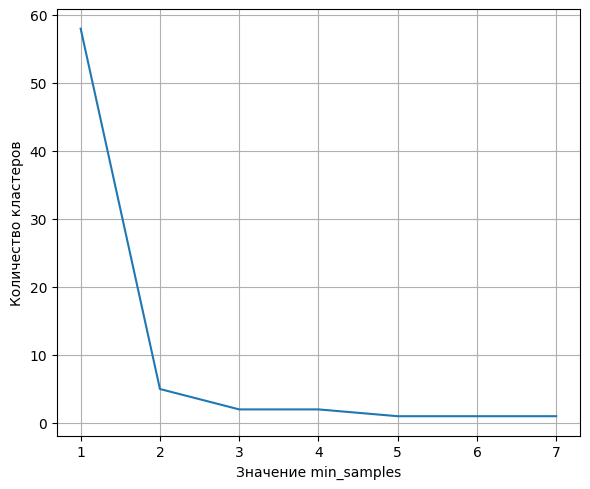

In [66]:
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))

# количество кластеров
sns.lineplot(x=min_samples_val, y=n_clusters, ax=ax1)
ax1.set_ylabel("Количество кластеров")
ax1.set_xlabel("Значение min_samples")
ax1.grid(True)

plt.tight_layout()

### Обучение финальных моделей
На основе графиков выбираются оптимальные гиперпараметры. Обучаются три версии KMeans (с разным количеством кластеров) и три версии DBSCAN (с разным радиусом). Модели работают исключительно с масштабированными признаками, без использования истинных жанров.

In [73]:
kmeans_1 = KMeans(n_clusters=3, random_state=42)
kmeans_1.fit(X_scaled)

kmeans_2 = KMeans(n_clusters=6, random_state=42)
kmeans_2.fit(X_scaled)

kmeans_3 = KMeans(n_clusters=9, random_state=42)
kmeans_3.fit(X_scaled)

dbscan_1 = DBSCAN(eps = 4.1, min_samples = 11)
dbscan_1.fit(X_scaled)

dbscan_2 = DBSCAN(eps = 4.6, min_samples = 11)
dbscan_2.fit(X_scaled)

dbscan_3 = DBSCAN(eps = 5.6, min_samples = 11)
dbscan_3.fit(X_scaled)

DBSCAN(eps=5.6, min_samples=11)

### Оценка качества кластеризации
Предсказанные метки сравниваются с истинными жанрами с помощью скорректированного индекса Рэнда (ARI) и взаимной информации (AMI). Обе метрики учитывают вероятность случайного совпадения и корректно работают при разном количестве кластеров.

In [74]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

models = [("KMeans (n_clusters=3)", kmeans_1.labels_),
          ("KMeans (n_clusters=6)", kmeans_2.labels_),
          ("KMeans (n_clusters=9)", kmeans_3.labels_),
          ("DBSCAN (eps=4.3, min_samples=11)", dbscan_1.labels_),
          ("DBSCAN (eps=4.9, min_samples=11)", dbscan_2.labels_),
          ("DBSCAN (eps=5.1, min_samples=11)", dbscan_3.labels_)]

results = []
for name, labels in models:
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)
    results.append({"Model": name, "ARI": ari, "AMI": ami})

results_df = pd.DataFrame(results)

# Вывод результатов
print(results_df.sort_values(by="ARI", ascending=False).to_string(index=False))

                           Model      ARI      AMI
           KMeans (n_clusters=6) 0.057471 0.096603
           KMeans (n_clusters=9) 0.054116 0.094290
           KMeans (n_clusters=3) 0.018604 0.053408
DBSCAN (eps=4.3, min_samples=11) 0.000021 0.000511
DBSCAN (eps=4.9, min_samples=11) 0.000019 0.000421
DBSCAN (eps=5.1, min_samples=11) 0.000009 0.000129


### Выводы по результатам кластеризации

Проведённый эксперимент показал, что ни одна из протестированных конфигураций алгоритмов KMeans и DBSCAN не продемонстрировала высокого качества кластеризации относительно истинных жанровых меток: значения ARI не превышают 0.06, AMI — 0.10.

Это указывает на то, что выбранные аудиохарактеристики (танцевальность, энергичность, валентность, темп и др.) слабо коррелируют с жанровой принадлежностью треков в рамках данного датасета. Возможные причины:
- Жанры в музыке определяются не только акустическими признаками, но и культурным контекстом, инструментарием, текстами, исторической принадлежностью — факторами, не отражёнными в числовых фичах.
- Внутри одного жанра может наблюдаться высокая вариативность звучания, что размывает границы между кластерами.
- Часть признаков (например, `key`, `mode`, `duration_ms`) может не нести смысловой нагрузки для задачи разделения по жанрам.

Таким образом, кластеризация по аудио-фичам позволяет выявить группы треков со схожим звучанием, но эти группы не совпадают с традиционной жанровой классификацией.